特征名称： ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
模型系数： [  37.90402135 -241.96436231  542.42875852  347.70384391 -931.48884588
  518.06227698  163.41998299  275.31790158  736.1988589    48.67065743]
模型截距： 151.34560453985995
训练集 MSE：2868.55
测试集 MSE：2900.19
测试集 RMSE：53.85
测试集 MAE：42.79
测试集 R²：0.453
前 5 个预测值： [139.55 179.52 134.04 291.42 123.79]


C:\Users\58473\AppData\Local\Temp\ipykernel_25196\2684848795.py:128: UserWarning: Glyph 178 (\N{SUPERSCRIPT TWO}) missing from font(s) SimHei.
  plt.tight_layout(rect=[0, 0, 1, 0.96])
C:\Users\58473\AppData\Local\Temp\ipykernel_25196\2684848795.py:129: UserWarning: Glyph 178 (\N{SUPERSCRIPT TWO}) missing from font(s) SimHei.
  plt.savefig('./pictures/线性回归.png',dpi = 300)
d:\miniconda\envs\6661kai\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 178 (\N{SUPERSCRIPT TWO}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)


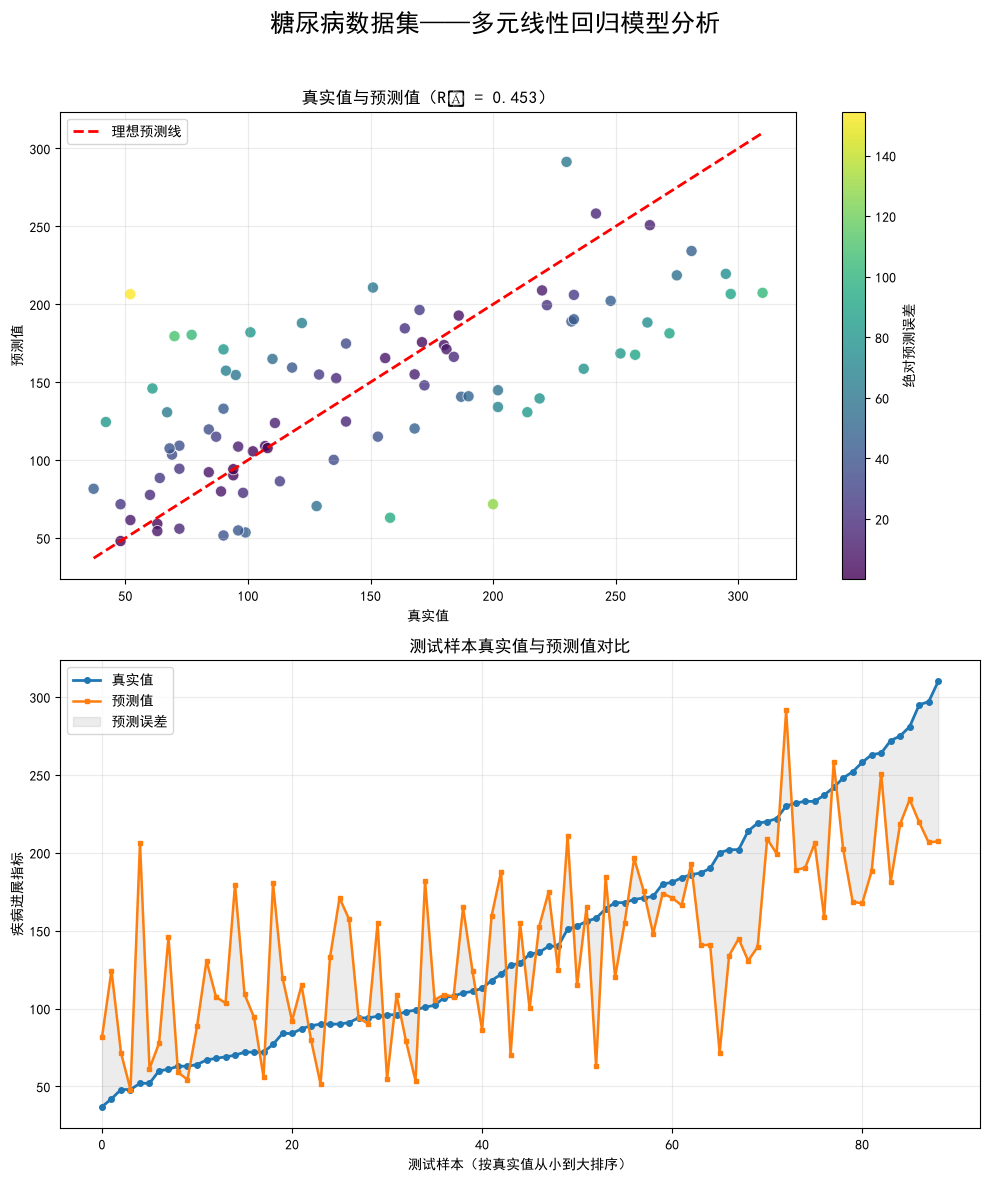

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 中文显示设置
plt.rcParams["font.sans-serif"] = ["SimHei", "Microsoft YaHei", "Arial Unicode MS"]
plt.rcParams["axes.unicode_minus"] = False

# 1. 加载数据
diabetes = load_diabetes()
X = diabetes.data
y = diabetes.target
feature_names = diabetes.feature_names

# 2. 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# 3. 训练线性回归模型
model = LinearRegression()
model.fit(X_train, y_train)

# 4. 模型预测与评估
y_train_pred = model.predict(X_train)
y_pred = model.predict(X_test)

train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_pred)
test_rmse = np.sqrt(test_mse)
test_mae = mean_absolute_error(y_test, y_pred)
test_r2 = r2_score(y_test, y_pred)
residuals = y_test - y_pred

print("特征名称：", feature_names)
print("模型系数：", model.coef_)
print("模型截距：", model.intercept_)
print(f"训练集 MSE：{train_mse:.2f}")
print(f"测试集 MSE：{test_mse:.2f}")
print(f"测试集 RMSE：{test_rmse:.2f}")
print(f"测试集 MAE：{test_mae:.2f}")
print(f"测试集 R²：{test_r2:.3f}")
print("前 5 个预测值：", np.round(y_pred[:5], 2))

# 5. 创建综合可视化（竖向排列，2行1列）
fig, axes = plt.subplots(2, 1, figsize=(10, 12))  # 改成2行1列
fig.suptitle("糖尿病数据集——多元线性回归模型分析", fontsize=18, fontweight="bold")

# 图1：真实值与预测值（散点图）
ax = axes[0]
scatter = ax.scatter(
    y_test, y_pred,
    c=np.abs(residuals),
    cmap="viridis",
    s=65,
    alpha=0.8,
    edgecolors="white",
    linewidths=0.6
)

value_min = min(y_test.min(), y_pred.min())
value_max = max(y_test.max(), y_pred.max())

ax.plot(
    [value_min, value_max],
    [value_min, value_max],
    color="red",
    linestyle="--",
    linewidth=2,
    label="理想预测线"
)

ax.set(
    title=f"真实值与预测值（R² = {test_r2:.3f}）",
    xlabel="真实值",
    ylabel="预测值"
)
ax.legend()
ax.grid(alpha=0.25)
cbar = fig.colorbar(scatter, ax=ax)
cbar.set_label("绝对预测误差")

# 图2：按真实值排序后的预测对比（折线图）
ax = axes[1]
sort_index = np.argsort(y_test)
sorted_true = y_test[sort_index]
sorted_pred = y_pred[sort_index]
sample_index = np.arange(len(y_test))

ax.plot(
    sample_index, sorted_true,
    color="#1f77b4",
    marker="o",
    markersize=4,
    linewidth=2,
    label="真实值"
)
ax.plot(
    sample_index, sorted_pred,
    color="#ff7f0e",
    marker="s",
    markersize=3,
    linewidth=1.8,
    label="预测值"
)
ax.fill_between(
    sample_index,
    sorted_true,
    sorted_pred,
    color="gray",
    alpha=0.15,
    label="预测误差"
)

ax.set(
    title="测试样本真实值与预测值对比",
    xlabel="测试样本（按真实值从小到大排序）",
    ylabel="疾病进展指标"
)
ax.legend()
ax.grid(alpha=0.25)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('./pictures/线性回归.png',dpi = 300)
plt.show()

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


不进行特征缩放的最终训练 MSE：2284.03
进行标准化后的最终训练 MSE：2.80


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


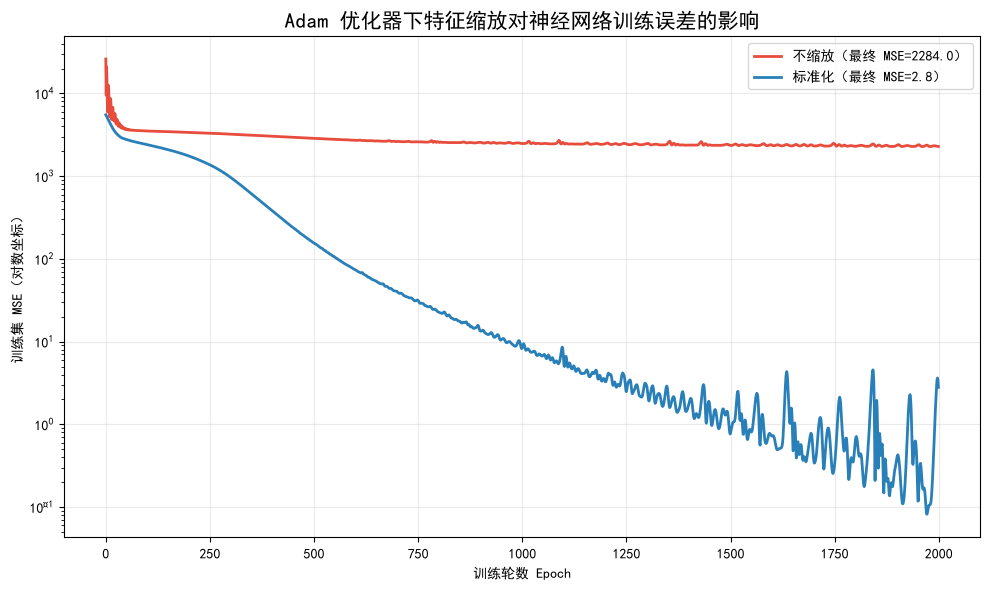

In [15]:
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 中文显示
plt.rcParams["font.sans-serif"] = ["SimHei", "Microsoft YaHei", "Arial Unicode MS"]
plt.rcParams["axes.unicode_minus"] = False

# 固定随机种子
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

# 加载未经缩放的糖尿病数据
diabetes = load_diabetes(scaled=False)
X = diabetes.data.astype(np.float32)
y = diabetes.target.astype(np.float32).reshape(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# 实验1：不进行特征缩放
X_train_raw = X_train.copy()

# 实验2：使用标准化
feature_scaler = StandardScaler()
X_train_scaled = feature_scaler.fit_transform(X_train).astype(np.float32)

# 两组实验都对目标值做相同处理，使神经网络训练更加稳定
y_mean = y_train.mean()
y_std = y_train.std()
y_train_normalized = ((y_train - y_mean) / y_std).astype(np.float32)

y_train_tensor = torch.tensor(y_train_normalized, dtype=torch.float32)


# 使用需要迭代优化的多层神经网络
class DiabetesMLP(nn.Module):
    def __init__(self, input_size):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.network(x)


def train_model(X_train_data, epochs=2000, learning_rate=0.001):
    # 保证两组模型的初始参数完全一致
    torch.manual_seed(seed)

    X_tensor = torch.tensor(X_train_data, dtype=torch.float32)

    model = DiabetesMLP(X_train_data.shape[1])
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=learning_rate
    )
    loss_function = nn.MSELoss()

    train_mse_history = []

    for epoch in range(epochs):
        model.train()

        prediction_normalized = model(X_tensor)
        loss = loss_function(prediction_normalized, y_train_tensor)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # 还原到糖尿病目标值的原始尺度后计算训练 MSE
        with torch.no_grad():
            prediction_original = (
                prediction_normalized * y_std + y_mean
            )
            original_mse = torch.mean(
                (prediction_original -
                 torch.tensor(y_train, dtype=torch.float32)) ** 2
            )

        train_mse_history.append(original_mse.item())

    return np.array(train_mse_history)


# 使用完全相同的 Adam 参数训练
epochs = 2000
learning_rate = 0.001

raw_mse_history = train_model(
    X_train_raw,
    epochs=epochs,
    learning_rate=learning_rate
)

scaled_mse_history = train_model(
    X_train_scaled,
    epochs=epochs,
    learning_rate=learning_rate
)

# 输出最终训练误差
print(f"不进行特征缩放的最终训练 MSE：{raw_mse_history[-1]:.2f}")
print(f"进行标准化后的最终训练 MSE：{scaled_mse_history[-1]:.2f}")

# 训练误差
plt.figure(figsize=(10, 6))

plt.plot(
    raw_mse_history,
    color="#E74C3C",
    linewidth=2,
    label=f"不缩放（最终 MSE={raw_mse_history[-1]:.1f}）"
)

plt.plot(
    scaled_mse_history,
    color="#2980B9",
    linewidth=2,
    label=f"标准化（最终 MSE={scaled_mse_history[-1]:.1f}）"
)

# 使用对数坐标，更容易观察两条曲线的收敛差异
plt.yscale("log")

plt.title(
    "Adam 优化器下特征缩放对神经网络训练误差的影响",
    fontsize=15,
    fontweight="bold"
)
plt.xlabel("训练轮数 Epoch")
plt.ylabel("训练集 MSE（对数坐标）")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig('特征缩放.png')
plt.show()

findfont: Failed to find font weight bold, now using 400.


训练集准确率：96.67%
测试集准确率：93.33%
模型迭代次数： [12]


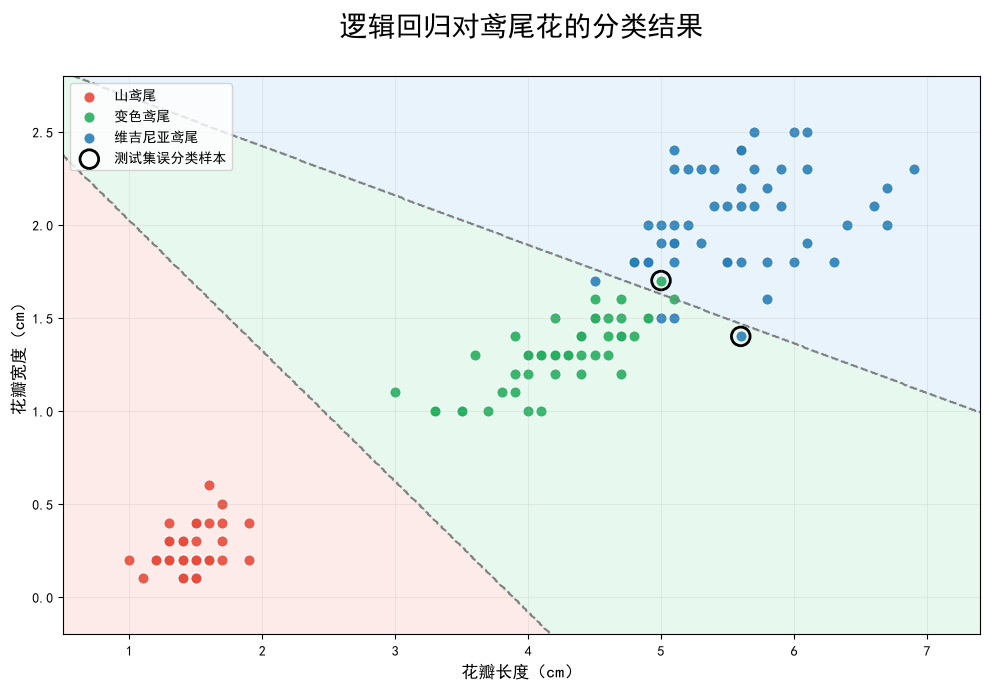

In [18]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from matplotlib.colors import ListedColormap

# 中文显示设置
plt.rcParams["font.sans-serif"] = [
    "SimHei", "Microsoft YaHei", "Arial Unicode MS", "DejaVu Sans"
]
plt.rcParams["axes.unicode_minus"] = False

# 1. 加载鸢尾花数据集
iris = load_iris()

# 只选择两个特征进行训练
#   花瓣长度 petal length
#   花瓣宽度 petal width
X = iris.data[:, [2, 3]]
y = iris.target

feature_names = ["花瓣长度（cm）", "花瓣宽度（cm）"]
class_names = ["山鸢尾", "变色鸢尾", "维吉尼亚鸢尾"]

# 2. 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 3. 特征标准化
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. 训练多分类逻辑回归模型
model = LogisticRegression(
    solver="lbfgs",
    max_iter=1000,
    random_state=42
)
model.fit(X_train_scaled, y_train)

# 5. 计算训练集和测试集准确率
train_prediction = model.predict(X_train_scaled)
test_prediction = model.predict(X_test_scaled)

train_accuracy = accuracy_score(y_train, train_prediction)
test_accuracy = accuracy_score(y_test, test_prediction)

print(f"训练集准确率：{train_accuracy:.2%}")
print(f"测试集准确率：{test_accuracy:.2%}")
print("模型迭代次数：", model.n_iter_)

# 6. 构建决策区域网格
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.3, X[:, 1].max() + 0.3

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 600),
    np.linspace(y_min, y_max, 500)
)

grid_points = np.c_[xx.ravel(), yy.ravel()]

# 模型基于标准化数据训练，因此网格点也需要使用相同的标准化器
grid_points_scaled = scaler.transform(grid_points)
grid_prediction = model.predict(grid_points_scaled)
grid_prediction = grid_prediction.reshape(xx.shape)

# 7. 只生成一张可视化图片
background_colors = ListedColormap([
    "#FADBD8",
    "#D5F5E3",
    "#D6EAF8"
])

point_colors = [
    "#E74C3C",
    "#27AE60",
    "#2980B9"
]

plt.figure(figsize=(10, 7))

# 绘制模型的分类区域
plt.contourf(
    xx,
    yy,
    grid_prediction,
    alpha=0.55,
    cmap=background_colors
)

# 绘制分类边界
##### 先预测每个节点的类型是什么，再
plt.contour(
    xx,
    yy,
    grid_prediction,
    levels=[0.5, 1.5],
    colors="gray",
    linewidths=1.5,
    linestyles="--"
)

# 绘制不同类别的鸢尾花样本
for class_id, class_name, color in zip(
    np.unique(y),
    class_names,
    point_colors
):
    plt.scatter(
        X[y == class_id, 0],
        X[y == class_id, 1],
        color=color,
        s=65,
        edgecolor="white",
        linewidth=0.8,
        alpha=0.9,
        label=class_name
    )

# 单独标记被错误分类的测试样本
test_prediction_original = model.predict(
    scaler.transform(X_test)
)
wrong_mask = test_prediction_original != y_test

if np.any(wrong_mask):
    plt.scatter(
        X_test[wrong_mask, 0],
        X_test[wrong_mask, 1],
        facecolors="none",
        edgecolors="black",
        s=180,
        linewidths=2,
        marker="o",
        label="测试集误分类样本"
    )

plt.title(
    f"逻辑回归对鸢尾花的分类结果\n",
    fontsize=20,
    fontweight="bold"
)
plt.xlabel(feature_names[0], fontsize=12)
plt.ylabel(feature_names[1], fontsize=12)
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.savefig('./pictures/逻辑回归')
plt.show()

随机森林中各棵树的深度：
[4 6 4 5 4 5 5 5 5 5 5 5 3 6 4 5 6 5 8 6 5 4 5 5 4 5 6 5 3 4 6 5 4 4 4 5 6
 4 5 6 5 4 4 7 5 4 3 5 6 4 5 4 5 4 4 5 5 7 4 5 4 5 6 4 4 3 6 4 6 5 5 4 5 4
 5 4 4 3 4 4 5 5 5 5 6 5 6 6 4 5 8 6 4 5 6 4 5 4 6 5]

随机森林平均树深度：4.85
单棵决策树采用的固定深度：5

各阶段训练损失对比：
-------------------------------------------------------------------
树/Boost轮数      决策树损失            随机森林损失           XGBoost损失        
10             0.000000         0.030675         0.371943         
20             0.000000         0.031019         0.163234         
30             0.000000         0.030198         0.086611         
40             0.000000         0.029599         0.053454         
50             0.000000         0.029101         0.037896         
60             0.000000         0.027711         0.030313         
70             0.000000         0.028360         0.027322         
80             0.000000         0.027728         0.025244         
90             0.000000         0.027645         0.023729         
10

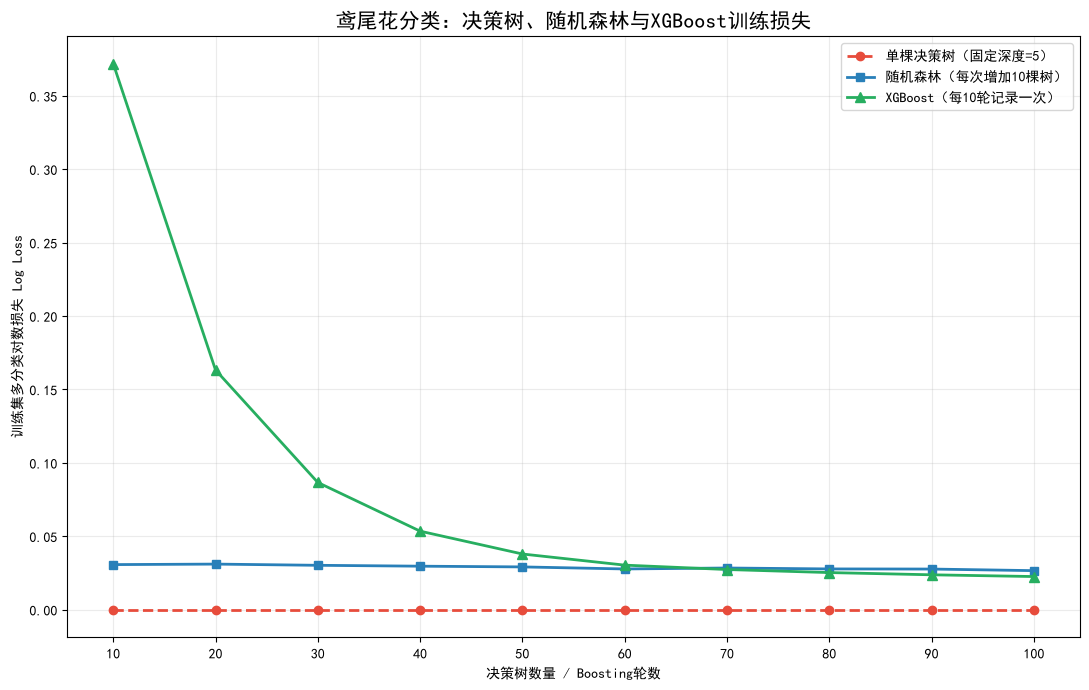

In [22]:
# 对比方式：
# 1. 随机森林每次增加10棵树，记录一次训练集Log Loss
# 2. XGBoost每完成10轮Boosting，记录一次训练集Log Loss
# 3. 单棵决策树的深度固定为随机森林中所有树的平均深度
# 4. 决策树只训练一次，因此它在每个横坐标上的损失相同

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import log_loss, accuracy_score
from xgboost import XGBClassifier

# 中文显示
plt.rcParams["font.sans-serif"] = [
    "SimHei", "Microsoft YaHei", "Arial Unicode MS", "DejaVu Sans"
]
plt.rcParams["axes.unicode_minus"] = False

# ============================================================
# 1. 加载鸢尾花数据
# ============================================================
iris = load_iris()
X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

class_labels = np.unique(y)

# 每个阶段增加10棵树或进行10轮Boosting
trees_per_step = 10
number_of_steps = 10

# 10、20、30、……、100
training_stages = np.arange(
    trees_per_step,
    trees_per_step * number_of_steps + 1,
    trees_per_step
)

total_trees = training_stages[-1]

# ============================================================
# 2. 随机森林
#    每次在已有森林中增加10棵树
# ============================================================
random_forest_model = RandomForestClassifier(
    n_estimators=trees_per_step,
    warm_start=True,
    max_depth=None,
    criterion="log_loss",
    random_state=42,
    n_jobs=-1
)

random_forest_losses = []
random_forest_accuracies = []

for number_of_trees in training_stages:
    # warm_start=True，因此新一轮只增加新的树
    random_forest_model.set_params(
        n_estimators=number_of_trees
    )

    random_forest_model.fit(X_train, y_train)

    train_probability = random_forest_model.predict_proba(X_train)
    train_prediction = random_forest_model.predict(X_train)

    current_loss = log_loss(
        y_train,
        train_probability,
        labels=class_labels
    )

    current_accuracy = accuracy_score(
        y_train,
        train_prediction
    )

    random_forest_losses.append(current_loss)
    random_forest_accuracies.append(current_accuracy)

# 计算最终随机森林中所有树的深度
forest_tree_depths = np.array([
    tree.tree_.max_depth
    for tree in random_forest_model.estimators_
])

average_forest_depth = forest_tree_depths.mean()

# 决策树深度必须为整数，使用四舍五入后的平均深度
fixed_tree_depth = max(1, int(round(average_forest_depth)))

print("随机森林中各棵树的深度：")
print(forest_tree_depths)
print(f"\n随机森林平均树深度：{average_forest_depth:.2f}")
print(f"单棵决策树采用的固定深度：{fixed_tree_depth}")

# ============================================================
# 3. 训练一棵固定深度的决策树
# ============================================================
decision_tree_model = DecisionTreeClassifier(
    max_depth=fixed_tree_depth,
    criterion="log_loss",
    random_state=42
)

decision_tree_model.fit(X_train, y_train)

tree_train_probability = decision_tree_model.predict_proba(X_train)
tree_train_prediction = decision_tree_model.predict(X_train)

decision_tree_loss = log_loss(
    y_train,
    tree_train_probability,
    labels=class_labels
)

decision_tree_accuracy = accuracy_score(
    y_train,
    tree_train_prediction
)

# 决策树没有逐步增加树的过程，因此每个阶段的值相同
decision_tree_losses = np.full(
    number_of_steps,
    decision_tree_loss
)

# ============================================================
# 4. 训练XGBoost
#    每进行10轮Boosting，提取一次训练损失
# ============================================================
xgboost_model = XGBClassifier(
    n_estimators=total_trees,
    max_depth=fixed_tree_depth,
    learning_rate=0.1,
    objective="multi:softprob",
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1
)

xgboost_model.fit(
    X_train,
    y_train,
    eval_set=[(X_train, y_train)],
    verbose=False
)

# 取得每一轮Boosting的训练损失
all_xgboost_losses = np.array(
    xgboost_model.evals_result()["validation_0"]["mlogloss"]
)

# 选择第10、20、30、……、100轮的结果
# 数组索引从0开始，所以使用9、19、29、……、99
xgboost_losses = all_xgboost_losses[
    training_stages - 1
]

# ============================================================
# 5. 输出各阶段结果
# ============================================================
print("\n各阶段训练损失对比：")
print("-" * 67)
print(
    f"{'树/Boost轮数':<15}"
    f"{'决策树损失':<17}"
    f"{'随机森林损失':<17}"
    f"{'XGBoost损失':<17}"
)

for stage, tree_loss, forest_loss, xgb_loss in zip(
    training_stages,
    decision_tree_losses,
    random_forest_losses,
    xgboost_losses
):
    print(
        f"{stage:<15}"
        f"{tree_loss:<17.6f}"
        f"{forest_loss:<17.6f}"
        f"{xgb_loss:<17.6f}"
    )

print("\n最终训练结果：")
print(
    f"单棵决策树：深度={fixed_tree_depth}，"
    f"Log Loss={decision_tree_loss:.6f}，"
    f"准确率={decision_tree_accuracy:.2%}"
)
print(
    f"随机森林：树数量={total_trees}，"
    f"Log Loss={random_forest_losses[-1]:.6f}，"
    f"准确率={random_forest_accuracies[-1]:.2%}"
)
print(
    f"XGBoost：Boosting轮数={total_trees}，"
    f"Log Loss={xgboost_losses[-1]:.6f}，"
    f"准确率={xgboost_model.score(X_train, y_train):.2%}"
)

# ============================================================
# 6. 只绘制一张训练损失对比图
# ============================================================
plt.figure(figsize=(11, 7))

plt.plot(
    training_stages,
    decision_tree_losses,
    color="#E74C3C",
    marker="o",
    markersize=6,
    linewidth=2,
    linestyle="--",
    label=f"单棵决策树（固定深度={fixed_tree_depth}）"
)

plt.plot(
    training_stages,
    random_forest_losses,
    color="#2980B9",
    marker="s",
    markersize=6,
    linewidth=2,
    label="随机森林（每次增加10棵树）"
)

plt.plot(
    training_stages,
    xgboost_losses,
    color="#27AE60",
    marker="^",
    markersize=7,
    linewidth=2,
    label="XGBoost（每10轮记录一次）"
)

plt.title(
    "鸢尾花分类：决策树、随机森林与XGBoost训练损失",
    fontsize=15,
    fontweight="bold"
)
plt.xlabel("决策树数量 / Boosting轮数")
plt.ylabel("训练集多分类对数损失 Log Loss")
plt.xticks(training_stages)
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.savefig('./pictures/决策树')
plt.show()

训练的二分类SVM数量： 3
测试集准确率：82.22%


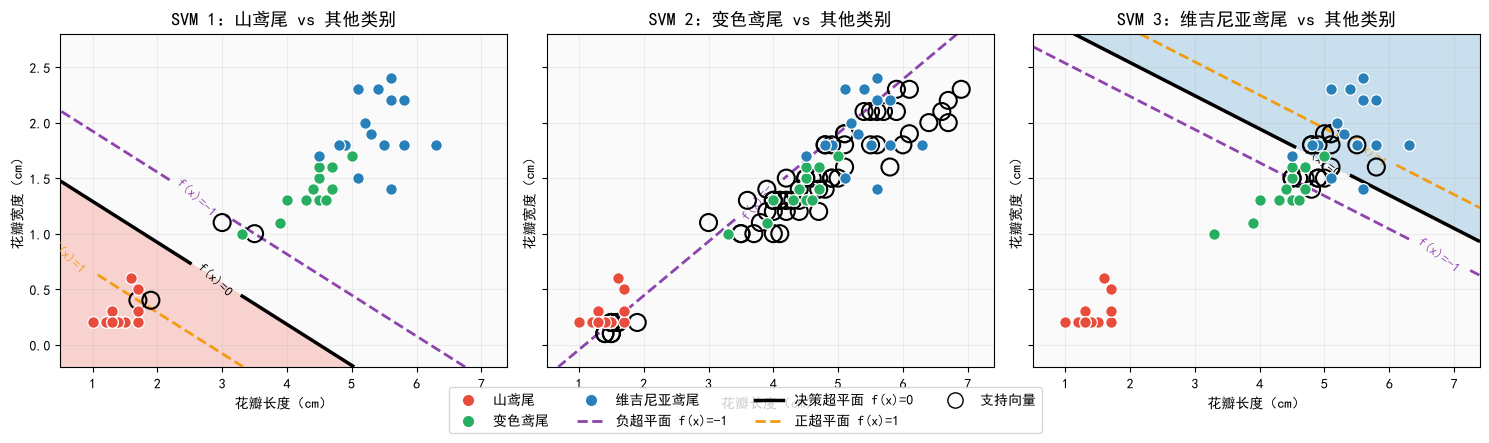

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import accuracy_score
from matplotlib.colors import ListedColormap
from matplotlib.lines import Line2D

# 中文显示
plt.rcParams["font.sans-serif"] = [
    "SimHei", "Microsoft YaHei", "Arial Unicode MS", "DejaVu Sans"
]
plt.rcParams["axes.unicode_minus"] = False

# ============================================================
# 1. 加载数据并选择区分最明显的两个特征
# ============================================================
iris = load_iris()

# 第3列：花瓣长度；第4列：花瓣宽度
X = iris.data[:, [2, 3]]
y = iris.target

feature_names = ["花瓣长度（cm）", "花瓣宽度（cm）"]
class_names = ["山鸢尾", "变色鸢尾", "维吉尼亚鸢尾"]

class_colors = [
    "#E74C3C",
    "#27AE60",
    "#2980B9"
]

# ============================================================
# 2. 划分训练集和测试集
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# ============================================================
# 3. 特征标准化
# ============================================================
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ============================================================
# 4. 使用One-vs-Rest训练3个线性SVM
# ============================================================
# 鸢尾花有3个类别，因此OneVsRestClassifier会训练3个SVM
base_svm = SVC(
    kernel="linear",
    C=1.0
)

ovr_model = OneVsRestClassifier(base_svm)
ovr_model.fit(X_train_scaled, y_train)

print("训练的二分类SVM数量：", len(ovr_model.estimators_))

# 最终多分类预测
y_prediction = ovr_model.predict(X_test_scaled)
test_accuracy = accuracy_score(y_test, y_prediction)

print(f"测试集准确率：{test_accuracy:.2%}")

# ============================================================
# 5. 构建二维坐标网格
# ============================================================
x_min = X[:, 0].min() - 0.5
x_max = X[:, 0].max() + 0.5
y_min = X[:, 1].min() - 0.3
y_max = X[:, 1].max() + 0.3

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 600),
    np.linspace(y_min, y_max, 500)
)

grid_points = np.c_[xx.ravel(), yy.ravel()]

# 模型使用标准化数据训练，网格点也必须使用同一个scaler
grid_points_scaled = scaler.transform(grid_points)

# ============================================================
# 6. 计算每个SVM在所有网格点上的决策函数值
# ============================================================
decision_surfaces = []

for binary_svm in ovr_model.estimators_:
    decision_value = binary_svm.decision_function(
        grid_points_scaled#计算标准化后的网格点
    )
    #计算后的数据格式是一维的，需要进行形状转换
    decision_surface = decision_value.reshape(xx.shape)
    decision_surfaces.append(decision_surface)

decision_surfaces = np.array(decision_surfaces)

# One-vs-Rest最终分类：
# 选择决策函数值最大的SVM所对应的类别
combined_prediction = np.argmax(
    decision_surfaces,
    axis=0
)

# ============================================================
# 7. 绘图辅助函数
# ============================================================
def draw_test_samples(ax):
    """在图中绘制测试集数据。"""

    for class_id, class_name, color in zip(
        range(3),
        class_names,
        class_colors
    ):
        mask = y_test == class_id

        ax.scatter(
            X_test[mask, 0],
            X_test[mask, 1],
            color=color,
            s=70,
            edgecolor="white",
            linewidth=0.9,
            label=class_name,
            zorder=5
        )


# ============================================================
# 8. 创建4个子图
# ============================================================
fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 5),
    sharex=True,
    sharey=True
)

# ------------------------------------------------------------
# 前三个子图：分别显示3个二分类SVM
# ------------------------------------------------------------
for class_id in range(3):
    ax = axes.ravel()[class_id]
    surface = decision_surfaces[class_id]

    # f(x)>0：模型判断为当前类别
    # f(x)<0：模型判断为其他类别
    binary_region = (surface >= 0).astype(int)

    ax.contourf(
        xx,
        yy,
        binary_region,
        levels=[-0.5, 0.5, 1.5],
        colors=["#EEEEEE", class_colors[class_id]],
        alpha=0.25
    )

    # 负超平面：w·x+b=-1
    negative_margin = ax.contour(
        xx,
        yy,
        surface,
        levels=[-1],
        colors="#8E44AD",
        linewidths=2,
        linestyles="--"
    )

    # 中间决策超平面：w·x+b=0
    decision_boundary = ax.contour(
        xx,
        yy,
        surface,
        levels=[0],
        colors="black",
        linewidths=2.5,
        linestyles="-"
    )

    # 正超平面：w·x+b=1
    positive_margin = ax.contour(
        xx,
        yy,
        surface,
        levels=[1],
        colors="#F39C12",
        linewidths=2,
        linestyles="--"
    )

    # 给超平面添加文字
    ax.clabel(
        negative_margin,
        fmt={-1: "f(x)=-1"},
        fontsize=9
    )

    ax.clabel(
        decision_boundary,
        fmt={0: "f(x)=0"},
        fontsize=9
    )

    ax.clabel(
        positive_margin,
        fmt={1: "f(x)=1"},
        fontsize=9
    )

    # 绘制测试集样本
    draw_test_samples(ax)

    # 标出当前二分类SVM的支持向量
    support_vectors_original = scaler.inverse_transform(
        ovr_model.estimators_[class_id].support_vectors_
    )

    ax.scatter(
        support_vectors_original[:, 0],
        support_vectors_original[:, 1],
        s=150,
        facecolors="none",
        edgecolors="black",
        linewidths=1.5,
        marker="o",
        zorder=4
    )

    ax.set_title(
        f"SVM {class_id + 1}：{class_names[class_id]} vs 其他类别",
        fontsize=13,
        fontweight="bold"
    )
    ax.set_xlabel(feature_names[0])
    ax.set_ylabel(feature_names[1])
    ax.grid(alpha=0.2)


# ============================================================
# 9. 添加统一图例
# ============================================================
legend_elements = [
    Line2D(
        [0], [0],
        marker="o",
        color="white",
        markerfacecolor=class_colors[0],
        markeredgecolor="white",
        markersize=9,
        label=class_names[0]
    ),
    Line2D(
        [0], [0],
        marker="o",
        color="white",
        markerfacecolor=class_colors[1],
        markeredgecolor="white",
        markersize=9,
        label=class_names[1]
    ),
    Line2D(
        [0], [0],
        marker="o",
        color="white",
        markerfacecolor=class_colors[2],
        markeredgecolor="white",
        markersize=9,
        label=class_names[2]
    ),
    Line2D(
        [0], [0],
        color="#8E44AD",
        linewidth=2,
        linestyle="--",
        label="负超平面 f(x)=-1"
    ),
    Line2D(
        [0], [0],
        color="black",
        linewidth=2.5,
        linestyle="-",
        label="决策超平面 f(x)=0"
    ),
    Line2D(
        [0], [0],
        color="#F39C12",
        linewidth=2,
        linestyle="--",
        label="正超平面 f(x)=1"
    ),
    Line2D(
        [0], [0],
        marker="o",
        color="black",
        markerfacecolor="none",
        markersize=11,
        linewidth=0,
        label="支持向量"
    )
]

fig.legend(
    handles=legend_elements,
    loc="lower center",
    ncol=4,
    bbox_to_anchor=(0.5, 0.01)
)


plt.tight_layout(rect=[0, 0.04, 1, 0.90])
plt.savefig('./pictures/svm')
plt.show()

d:\miniconda\envs\6661kai\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


调整兰德指数 ARI：0.886
轮廓系数：0.674

聚类中心：
簇0：花瓣长度=5.57 cm，花瓣宽度=2.06 cm
簇1：花瓣长度=1.46 cm，花瓣宽度=0.25 cm
簇2：花瓣长度=4.30 cm，花瓣宽度=1.32 cm


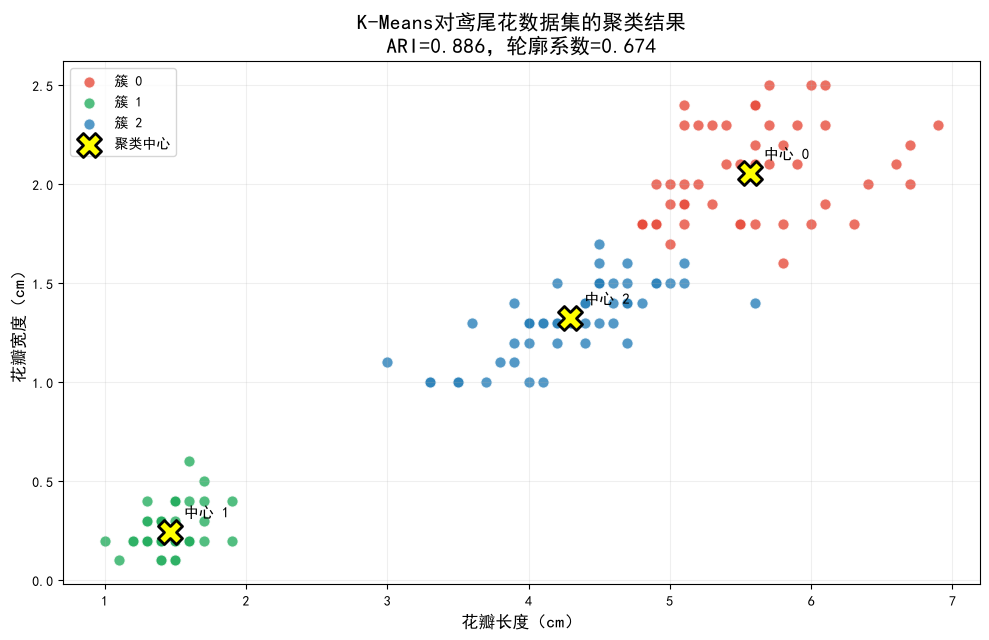

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import adjusted_rand_score, silhouette_score

# 中文显示
plt.rcParams["font.sans-serif"] = [
    "SimHei", "Microsoft YaHei", "Arial Unicode MS", "DejaVu Sans"
]
plt.rcParams["axes.unicode_minus"] = False

# 1. 加载鸢尾花数据集
iris = load_iris()

# 选择花瓣长度和花瓣宽度
X = iris.data[:, [2, 3]]
y_true = iris.target

feature_names = ["花瓣长度（cm）", "花瓣宽度（cm）"]

# 2. 特征标准化
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. K-Means聚类
kmeans = KMeans(
    n_clusters=3,
    n_init=20,
    random_state=42
)

cluster_labels = kmeans.fit_predict(X_scaled)

# 4. 计算评价指标
ari = adjusted_rand_score(y_true, cluster_labels)
silhouette = silhouette_score(X_scaled, cluster_labels)
#ARI指的是分类正确的比例
print(f"调整兰德指数 ARI：{ari:.3f}")
print(f"轮廓系数：{silhouette:.3f}")

# 将聚类中心还原到原始特征尺度
cluster_centers = scaler.inverse_transform(
    kmeans.cluster_centers_
)

print("\n聚类中心：")

for cluster_id, center in enumerate(cluster_centers):
    print(
        f"簇{cluster_id}："
        f"花瓣长度={center[0]:.2f} cm，"
        f"花瓣宽度={center[1]:.2f} cm"
    )

# 5. 绘制聚类结果
cluster_colors = [
    "#E74C3C",
    "#27AE60",
    "#2980B9"
]

plt.figure(figsize=(10, 6.5))

# 绘制各个簇的样本点
for cluster_id, color in enumerate(cluster_colors):
    mask = cluster_labels == cluster_id

    plt.scatter(
        X[mask, 0],
        X[mask, 1],
        color=color,
        s=65,
        alpha=0.8,
        edgecolor="white",
        linewidth=0.8,
        label=f"簇 {cluster_id}"
    )

# 只额外显示三个聚类中心
plt.scatter(
    cluster_centers[:, 0],
    cluster_centers[:, 1],
    color="yellow",
    marker="X",
    s=300,
    edgecolor="black",
    linewidth=2,
    label="聚类中心",
    zorder=5
)

# 标注聚类中心
for cluster_id, center in enumerate(cluster_centers):
    plt.annotate(
        f"中心 {cluster_id}",
        xy=(center[0], center[1]),
        xytext=(10, 10),
        textcoords="offset points",
        fontsize=11,
        fontweight="bold"
    )

plt.title(
    f"K-Means对鸢尾花数据集的聚类结果\n"
    f"ARI={ari:.3f}，轮廓系数={silhouette:.3f}",
    fontsize=15,
    fontweight="bold"
)
plt.xlabel(feature_names[0], fontsize=12)
plt.ylabel(feature_names[1], fontsize=12)
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.savefig('./pictures/kmeans')
plt.show()

In [34]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 1. 加载鸢尾花数据集
iris = load_iris()
X = iris.data

# 2. 对4个原始特征进行标准化
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. 使用PCA将4维数据降到2维
pca = PCA(n_components=4)
X_pca = pca.fit_transform(X_scaled)

# 4. 输出PCA特征向量矩阵
# 每一行对应一个主成分，每一列对应一个原始特征
feature_vector_matrix = pca.components_

np.set_printoptions(precision=4, suppress=True)

print("原始特征名称：")
print(iris.feature_names)

print("\nPCA特征向量矩阵：")
print(feature_vector_matrix)

print("\n特征向量矩阵形状：")
print(feature_vector_matrix.shape)

print("\n各主成分的方差贡献率：")
print(pca.explained_variance_ratio_)

原始特征名称：
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

PCA特征向量矩阵：
[[ 0.5211 -0.2693  0.5804  0.5649]
 [ 0.3774  0.9233  0.0245  0.0669]
 [ 0.7196 -0.2444 -0.1421 -0.6343]
 [-0.2613  0.1235  0.8014 -0.5236]]

特征向量矩阵形状：
(4, 4)

各主成分的方差贡献率：
[0.7296 0.2285 0.0367 0.0052]
